In [1]:
import os
from dotenv import load_dotenv

_ = load_dotenv()

In [2]:
import asyncio
import json
import operator
import re
from typing import Annotated, Any, NotRequired, TypedDict

from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langgraph.types import Send
from langgraph.graph import END, START, StateGraph

from tools.playwright_tools import broad_scrape, detailed_scrape
from tools.search_tools import search_web
from tools.database_tools import (
    build_event_composite,
    insert_canonical_name,
    upsert_event_record,
    vector_search_canonical_names,
    vector_search_events_by_composite,
)

In [ ]:
starting_page_url = "https://www.jacksonholehistory.org/"

In [4]:
class EventRecordType(TypedDict):
    event_name: str | None
    date: str | None
    time: str | None
    source_url: str | None
    event_main_url: str | None
    event_secondary_url: str | None
    event_address: str | None
    venue_name: str | None
    host_organization_name: str | None
    event_description: str | None
    event_status: str | None


class EventDbRecordType(TypedDict):
    id: str | None
    event_name: str | None
    event_date: str | None
    event_time: str | None
    source_url: str | None
    main_url: str | None
    secondary_url: str | None
    event_address: str | None
    venue_name: str | None
    host_organization_name: str | None
    event_description: str | None
    event_status: str | None
    event_composite: str | None


class SeriesAnalysisResultType(TypedDict):
    original_stub: EventRecordType
    classification: str
    reason: str
    series_confidence: float
    recurrence_confidence: float


class EventMergeCandidateType(TypedDict):
    original_stub: EventRecordType
    enrichment: EventRecordType


class PipelineStateType(TypedDict):
    starting_page_url: str
    source_url: NotRequired[str]
    loaded_page_url: NotRequired[str]
    loaded_page_text: NotRequired[str]
    broad_event_stubs: NotRequired[list[EventRecordType]]
    clean_event_stubs: NotRequired[list[EventRecordType]]
    series_analysis_results: NotRequired[list[SeriesAnalysisResultType]]
    single_event_stubs: NotRequired[list[EventRecordType]]
    series_hub_stubs: NotRequired[list[EventRecordType]]
    unresolved_series_stubs: NotRequired[list[EventRecordType]]
    expanded_series_event_stubs: NotRequired[list[EventRecordType]]
    final_event_stubs: NotRequired[list[EventRecordType]]
    current_event_stub: NotRequired[EventRecordType]
    merge_candidates: NotRequired[Annotated[list[EventMergeCandidateType], operator.add]]
    canonicalized_merge_candidates: NotRequired[Annotated[list[EventMergeCandidateType], operator.add]]
    final_events: Annotated[list[EventRecordType], operator.add]


class EventRecordModelType(BaseModel):
    event_name: str | None = Field(default=None)
    date: str | None = Field(default=None)
    time: str | None = Field(default=None)
    source_url: str | None = Field(default=None)
    event_main_url: str | None = Field(default=None)
    event_secondary_url: str | None = Field(default=None)
    event_address: str | None = Field(default=None)
    venue_name: str | None = Field(default=None)
    host_organization_name: str | None = Field(default=None)
    event_description: str | None = Field(default=None)
    event_status: str | None = Field(default=None)


class BroadEventCandidatesModelType(BaseModel):
    events: list[EventRecordModelType] = Field(default_factory=list)


class SeriesClassificationModelType(BaseModel):
    classification: str = Field(default="single_event")
    reason: str = Field(default="")
    series_confidence: float = Field(default=0.0)
    recurrence_confidence: float = Field(default=0.0)


class CanonicalCandidateModelType(BaseModel):
    id: str | None = Field(default=None)
    raw_name: str | None = Field(default=None)
    canonical_name: str | None = Field(default=None)
    website_url: str | None = Field(default=None)


class CanonicalMatchDecisionModelType(BaseModel):
    is_match: bool = Field(default=False)
    matched_result_index: int = Field(default=-1)
    canonical_name_to_use: str | None = Field(default=None)
    reason: str = Field(default="")


class EventDbCandidateModelType(BaseModel):
    id: str | None = Field(default=None)
    event_name: str | None = Field(default=None)
    event_date: str | None = Field(default=None)
    event_time: str | None = Field(default=None)
    source_url: str | None = Field(default=None)
    main_url: str | None = Field(default=None)
    secondary_url: str | None = Field(default=None)
    event_address: str | None = Field(default=None)
    venue_name: str | None = Field(default=None)
    host_organization_name: str | None = Field(default=None)
    event_description: str | None = Field(default=None)
    event_status: str | None = Field(default=None)
    event_composite: str | None = Field(default=None)


class EventDbMatchDecisionModelType(BaseModel):
    is_match: bool = Field(default=False)
    matched_result_index: int = Field(default=-1)
    event_description_to_use: str | None = Field(default=None)
    event_time_to_use: str | None = Field(default=None)
    event_status_to_use: str | None = Field(default=None)
    reason: str = Field(default="")


class EventEnrichmentModelType(BaseModel):
    event: EventRecordModelType = Field(default_factory=EventRecordModelType)

In [5]:
EVENT_LOCATION = "Jackson Hole, Wyoming"
DISCOVERY_PROMPT = """
You are the Broad Event Researcher in a two-phase event pipeline.

Task:
- Work only from the provided starting-page text.
- Identify event candidates and return rough event stubs.

Rules:
- Do not browse new pages.
- Do not invent values.
- Keep one stub per event candidate you can support from the text.
- If a field is unknown, return null.
- Keep source_url exactly as provided.
- Do not populate event_secondary_url during discovery; leave it null.

Return fields for each event:
- event_name
- date
- time
- source_url
- event_main_url
- event_secondary_url (always null in this phase)
- event_address
- venue_name
- host_organization_name
- event_description
- event_status
"""

SERIES_CLASSIFIER_PROMPT = """
You classify ONE event stub as one of:
- single_event
- recurring_event
- series_hub

Inputs:
- Full event stub JSON with all available fields.

How to classify:
- recurring_event: the same event repeats on a cadence (weekly/monthly/recurring) and does not represent many distinct child events.
- series_hub: a parent container for many distinct child events (for example concert series with different performers/dates).
- single_event: one concrete event occurrence.

Strong series_hub indicators:
- name includes plural or series language (Concerts, Series, Lineup, Schedule)
- description suggests multiple unique child events
- multiple different dates that represent different events, not one recurring pattern

Strong recurring_event indicators:
- explicit recurring cadence language (weekly, monthly, recurring)
- one event concept repeated over time

Return JSON fields:
- classification
- reason
- series_confidence (0 to 1)
- recurrence_confidence (0 to 1)
"""

ENRICHMENT_PROMPT = """
You are the Event Researcher in a two-phase event pipeline.

Task:
- You receive ONE known event stub.
- You receive detailed text blocks from that event's main and secondary pages.
- Fill missing fields first.
- Improve weak fields only when page evidence is clearly better.

Rules:
- Do not discover new events.
- Stay focused on the provided event.
- If uncertain, keep null.
- Preserve source_url from the event stub.

Return one enriched event object with the canonical fields.
"""

CANONICAL_MATCH_PROMPT = """
You decide if a name matches one of the canonical search results.

Inputs:
- name_type: venue_name or host_organization_name
- original_name
- top_k_results: up to 3 canonical candidates, each with canonical_name, raw_name, website_url

Rules:
- Return is_match=true only when one result is clearly the same real-world entity.
- If matched, set matched_result_index to the index in top_k_results and return canonical_name_to_use.
- If no clear match, return is_match=false and matched_result_index=-1.
- canonical_name_to_use may still suggest a normalized name for insertion when no match exists.

Return JSON fields:
- is_match
- matched_result_index
- canonical_name_to_use
- reason
"""

EVENT_DB_MATCH_PROMPT = """
You decide if an incoming event is the same event as one of the top vector candidates from the database.

Inputs:
- incoming_event: normalized event payload
- top_k_candidates: up to 3 DB event candidates

Rules:
- Return is_match=true only if one candidate is clearly the same event occurrence.
- Use event identity signals: event_name, event_date, host_organization_name, URLs, and venue.
- If matched, set matched_result_index to the best candidate index.
- If no clear same-event match, return is_match=false and matched_result_index=-1.
- If matched, provide best values for:
  - event_description_to_use (include new meaningful details)
  - event_time_to_use (use corrected/changed time when evidence supports it)
  - event_status_to_use (for example cancelled, postponed, scheduled, or null if unknown)

Return JSON fields:
- is_match
- matched_result_index
- event_description_to_use
- event_time_to_use
- event_status_to_use
- reason
"""

researchModel = ChatOpenAI(model="gpt-5-mini", temperature=0)

In [6]:
TARGET_FIELDS = [
    "event_name",
    "date",
    "time",
    "source_url",
    "event_main_url",
    "event_secondary_url",
    "event_address",
    "venue_name",
    "host_organization_name",
    "event_description",
    "event_status",
]


def normalize_text_value(raw_value: str | None) -> str | None:
    if raw_value is None:
        return None
    stripped_value = raw_value.strip()
    if not stripped_value:
        return None
    return re.sub(r"\s+", " ", stripped_value)


def normalize_event_record(record: EventRecordType, fallback_source_url: str | None = None) -> EventRecordType:
    normalized_record: EventRecordType = {
        field_name: normalize_text_value(record.get(field_name)) for field_name in TARGET_FIELDS
    }
    if normalized_record["source_url"] is None:
        normalized_record["source_url"] = normalize_text_value(fallback_source_url)
    return normalized_record


def normalize_event_db_record(record: dict[str, Any]) -> EventDbRecordType:
    normalized_record: EventDbRecordType = {
        "id": normalize_text_value(record.get("id")),
        "event_name": normalize_text_value(record.get("event_name")),
        "event_date": normalize_text_value(record.get("event_date")),
        "event_time": normalize_text_value(record.get("event_time")),
        "source_url": normalize_text_value(record.get("source_url")),
        "main_url": normalize_text_value(record.get("main_url")),
        "secondary_url": normalize_text_value(record.get("secondary_url")),
        "event_address": normalize_text_value(record.get("event_address")),
        "venue_name": normalize_text_value(record.get("venue_name")),
        "host_organization_name": normalize_text_value(record.get("host_organization_name")),
        "event_description": normalize_text_value(record.get("event_description")),
        "event_status": normalize_text_value(record.get("event_status")),
        "event_composite": normalize_text_value(record.get("event_composite")),
    }
    return normalized_record


def to_event_db_payload(event_record: EventRecordType) -> EventDbRecordType:
    normalized_event = normalize_event_record(event_record, fallback_source_url=event_record.get("source_url"))
    payload: EventDbRecordType = {
        "id": None,
        "event_name": normalize_text_value(normalized_event.get("event_name")),
        "event_date": normalize_text_value(normalized_event.get("date")),
        "event_time": normalize_text_value(normalized_event.get("time")),
        "source_url": normalize_text_value(normalized_event.get("source_url")),
        "main_url": normalize_text_value(normalized_event.get("event_main_url")),
        "secondary_url": normalize_text_value(normalized_event.get("event_secondary_url")),
        "event_address": normalize_text_value(normalized_event.get("event_address")),
        "venue_name": normalize_text_value(normalized_event.get("venue_name")),
        "host_organization_name": normalize_text_value(normalized_event.get("host_organization_name")),
        "event_description": normalize_text_value(normalized_event.get("event_description")),
        "event_status": normalize_text_value(normalized_event.get("event_status")),
        "event_composite": None,
    }
    payload["event_composite"] = normalize_text_value(
        build_event_composite(
            event_date=payload.get("event_date"),
            event_name=payload.get("event_name"),
            host_organization_name=payload.get("host_organization_name"),
        )
    )
    return payload


def normalize_classification_value(classification_value: str | None) -> str:
    normalized_value = (classification_value or "").strip().lower()
    if normalized_value not in {"single_event", "recurring_event", "series_hub"}:
        return "single_event"
    return normalized_value


async def extract_broad_event_stubs_from_page(
    source_url: str,
    page_text: str,
) -> list[EventRecordType]:
    structured_model = researchModel.with_structured_output(BroadEventCandidatesModelType)
    broad_candidates = await structured_model.ainvoke(
        [
            ("system", DISCOVERY_PROMPT),
            (
                "human",
                f"Source URL: {source_url}\n\nStarting page text:\n{page_text}",
            ),
        ]
    )

    broad_event_stubs: list[EventRecordType] = []
    for event_record in broad_candidates.events:
        normalized_stub = normalize_event_record(
            event_record.model_dump(),
            fallback_source_url=source_url,
        )
        normalized_stub["event_secondary_url"] = None
        broad_event_stubs.append(normalized_stub)
    return broad_event_stubs


def score_series_page_candidate(
    candidate_url: str,
    combined_text: str,
    event_name_value: str,
    venue_name_value: str,
    host_name_value: str,
    main_url_value: str | None,
) -> int:
    score_value = 0
    if event_name_value and event_name_value.lower() in combined_text:
        score_value += 5
    if venue_name_value and venue_name_value.lower() in combined_text:
        score_value += 2
    if host_name_value and host_name_value.lower() in combined_text:
        score_value += 2
    if EVENT_LOCATION.lower() in combined_text:
        score_value += 1
    if "series" in combined_text or "lineup" in combined_text or "schedule" in combined_text:
        score_value += 4
    if "/schedule" in candidate_url.lower() or "/series" in candidate_url.lower():
        score_value += 3
    if "/event/" in candidate_url.lower():
        score_value -= 2
    if "/listing/" in candidate_url.lower():
        score_value -= 2
    if main_url_value and candidate_url == main_url_value:
        score_value -= 6
    return score_value


def is_more_detailed(candidate_value: str | None, baseline_value: str | None) -> bool:
    if candidate_value is None:
        return False
    if baseline_value is None:
        return True
    return len(candidate_value) > len(baseline_value) + 15


def merge_prefer_detailed(stub: EventRecordType, enrichment: EventRecordType) -> EventRecordType:
    merged_record: EventRecordType = {}
    for field_name in TARGET_FIELDS:
        if field_name == "source_url":
            merged_record[field_name] = stub.get("source_url") or enrichment.get("source_url")
            continue

        stub_value = normalize_text_value(stub.get(field_name))
        enrichment_value = normalize_text_value(enrichment.get(field_name))

        if stub_value is None:
            merged_record[field_name] = enrichment_value
        elif is_more_detailed(enrichment_value, stub_value):
            merged_record[field_name] = enrichment_value
        else:
            merged_record[field_name] = stub_value

    return normalize_event_record(merged_record, fallback_source_url=stub.get("source_url"))

In [7]:
def _safe_metadata_string(value: Any) -> str | None:
    if value is None:
        return None
    text_value = normalize_text_value(str(value))
    return text_value


def _best_homepage_from_tavily(tavily_payload: object) -> str | None:
    if not isinstance(tavily_payload, dict):
        return None
    raw_results = tavily_payload.get("results", [])
    if not isinstance(raw_results, list):
        return None

    best_url: str | None = None
    best_score = -999
    for raw_result in raw_results:
        if not isinstance(raw_result, dict):
            continue
        candidate_url = _safe_metadata_string(raw_result.get("url"))
        if candidate_url is None:
            continue

        title_text = (_safe_metadata_string(raw_result.get("title")) or "").lower()
        content_text = (_safe_metadata_string(raw_result.get("content")) or "").lower()
        combined_text = f"{title_text} {content_text} {candidate_url.lower()}"

        score = 0
        if "/event/" in candidate_url.lower():
            score -= 3
        if "/listing/" in candidate_url.lower():
            score -= 2
        if "official" in combined_text:
            score += 2
        if "about" in candidate_url.lower() or "home" in candidate_url.lower():
            score += 1
        if "facebook.com" in candidate_url.lower() or "instagram.com" in candidate_url.lower():
            score -= 1

        if score > best_score:
            best_score = score
            best_url = candidate_url

    return best_url


async def _choose_canonical_name(
    name_type: str,
    original_name: str,
    candidates: list[dict[str, Any]],
) -> CanonicalMatchDecisionModelType:
    structured_model = researchModel.with_structured_output(CanonicalMatchDecisionModelType)
    decision = await structured_model.ainvoke(
        [
            ("system", CANONICAL_MATCH_PROMPT),
            (
                "human",
                "name_type: "
                + name_type
                + "\noriginal_name: "
                + original_name
                + "\ntop_k_results:\n"
                + json.dumps(candidates, ensure_ascii=True, indent=2),
            ),
        ]
    )
    return decision


async def canonicalize_name_field(
    name_type: str,
    original_name: str | None,
) -> tuple[str | None, dict[str, Any]]:
    normalized_original_name = normalize_text_value(original_name)
    diagnostics: dict[str, Any] = {
        "name_type": name_type,
        "original_name": normalized_original_name,
        "initial_result_count": 0,
        "fallback_result_count": 0,
        "used_tavily_fallback": False,
        "inserted_new_record": False,
    }

    if normalized_original_name is None:
        return None, diagnostics

    initial_results = await vector_search_canonical_names(
        query=normalized_original_name,
        name_type=name_type,
        k=3,
    )
    diagnostics["initial_result_count"] = len(initial_results)

    decision = await _choose_canonical_name(
        name_type=name_type,
        original_name=normalized_original_name,
        candidates=initial_results,
    )

    if decision.is_match and 0 <= decision.matched_result_index < len(initial_results):
        matched_result = initial_results[decision.matched_result_index]
        matched_canonical_name = _safe_metadata_string(matched_result.get("canonical_name"))
        if matched_canonical_name:
            diagnostics["match_path"] = "initial_vector_search"
            diagnostics["resolved_name"] = matched_canonical_name
            return matched_canonical_name, diagnostics

    tavily_payload = await asyncio.to_thread(search_web.invoke, {"query": normalized_original_name})
    homepage_url = _best_homepage_from_tavily(tavily_payload)
    diagnostics["used_tavily_fallback"] = True
    diagnostics["fallback_homepage_url"] = homepage_url

    fallback_query = normalized_original_name
    if homepage_url:
        fallback_query = f"{normalized_original_name} {homepage_url}"

    fallback_results = await vector_search_canonical_names(
        query=fallback_query,
        name_type=name_type,
        k=3,
    )
    diagnostics["fallback_result_count"] = len(fallback_results)

    fallback_decision = await _choose_canonical_name(
        name_type=name_type,
        original_name=normalized_original_name,
        candidates=fallback_results,
    )

    if fallback_decision.is_match and 0 <= fallback_decision.matched_result_index < len(fallback_results):
        matched_result = fallback_results[fallback_decision.matched_result_index]
        matched_canonical_name = _safe_metadata_string(matched_result.get("canonical_name"))
        if matched_canonical_name:
            diagnostics["match_path"] = "fallback_vector_search"
            diagnostics["resolved_name"] = matched_canonical_name
            return matched_canonical_name, diagnostics

    canonical_name_to_use = normalize_text_value(fallback_decision.canonical_name_to_use)
    if canonical_name_to_use is None:
        canonical_name_to_use = normalized_original_name

    await insert_canonical_name(
        raw_name=normalized_original_name,
        canonical_name=canonical_name_to_use,
        name_type=name_type,
        website_url=homepage_url,
    )
    diagnostics["inserted_new_record"] = True
    diagnostics["match_path"] = "inserted_new_canonical"
    diagnostics["resolved_name"] = canonical_name_to_use
    return canonical_name_to_use, diagnostics


async def choose_event_db_match(
    incoming_event: EventDbRecordType,
    top_k_candidates: list[EventDbRecordType],
) -> EventDbMatchDecisionModelType:
    structured_model = researchModel.with_structured_output(EventDbMatchDecisionModelType)
    return await structured_model.ainvoke(
        [
            ("system", EVENT_DB_MATCH_PROMPT),
            (
                "human",
                "incoming_event:\n"
                + json.dumps(incoming_event, ensure_ascii=True, indent=2)
                + "\n\ntop_k_candidates:\n"
                + json.dumps(top_k_candidates, ensure_ascii=True, indent=2),
            ),
        ]
    )


def merge_event_db_payload(
    existing_event: EventDbRecordType,
    incoming_event: EventDbRecordType,
    decision: EventDbMatchDecisionModelType,
) -> EventDbRecordType:
    merged_event: EventDbRecordType = {
        "id": normalize_text_value(existing_event.get("id")),
        "event_name": normalize_text_value(incoming_event.get("event_name"))
        or normalize_text_value(existing_event.get("event_name")),
        "event_date": normalize_text_value(incoming_event.get("event_date"))
        or normalize_text_value(existing_event.get("event_date")),
        "event_time": normalize_text_value(existing_event.get("event_time")),
        "source_url": normalize_text_value(incoming_event.get("source_url"))
        or normalize_text_value(existing_event.get("source_url")),
        "main_url": normalize_text_value(incoming_event.get("main_url"))
        or normalize_text_value(existing_event.get("main_url")),
        "secondary_url": normalize_text_value(incoming_event.get("secondary_url"))
        or normalize_text_value(existing_event.get("secondary_url")),
        "event_address": normalize_text_value(incoming_event.get("event_address"))
        or normalize_text_value(existing_event.get("event_address")),
        "venue_name": normalize_text_value(incoming_event.get("venue_name"))
        or normalize_text_value(existing_event.get("venue_name")),
        "host_organization_name": normalize_text_value(incoming_event.get("host_organization_name"))
        or normalize_text_value(existing_event.get("host_organization_name")),
        "event_description": normalize_text_value(existing_event.get("event_description")),
        "event_status": normalize_text_value(existing_event.get("event_status")),
        "event_composite": None,
    }

    description_value = normalize_text_value(decision.event_description_to_use)
    if description_value is None:
        description_value = normalize_text_value(incoming_event.get("event_description"))
    if description_value is not None:
        merged_event["event_description"] = description_value

    event_time_value = normalize_text_value(decision.event_time_to_use)
    if event_time_value is None:
        event_time_value = normalize_text_value(incoming_event.get("event_time"))
    if event_time_value is not None:
        merged_event["event_time"] = event_time_value

    event_status_value = normalize_text_value(decision.event_status_to_use)
    if event_status_value is None:
        event_status_value = normalize_text_value(incoming_event.get("event_status"))
    merged_event["event_status"] = event_status_value

    merged_event["event_composite"] = normalize_text_value(
        build_event_composite(
            event_date=merged_event.get("event_date"),
            event_name=merged_event.get("event_name"),
            host_organization_name=merged_event.get("host_organization_name"),
        )
    )
    return merged_event

In [8]:
## Used to load the starting page and get the source url
async def load_starting_page_node(state: PipelineStateType) -> PipelineStateType:
    starting_page_url = state["starting_page_url"]
    print(f"[load_starting_page] Start: loading starting URL -> {starting_page_url}")

    broad_scrape_result = await broad_scrape.ainvoke({"url": starting_page_url})

    source_url = normalize_text_value(starting_page_url)
    loaded_page_url = normalize_text_value(str(broad_scrape_result.get("final_url", "")))
    loaded_page_text = normalize_text_value(str(broad_scrape_result.get("body_text", "")))

    print(
        "[load_starting_page] Done: prepared page payload "
        f"(loaded_page_url={loaded_page_url or source_url}, text_chars={len(loaded_page_text or '')})"
    )

    return {
        "source_url": source_url or "",
        "loaded_page_url": loaded_page_url or source_url or "",
        "loaded_page_text": loaded_page_text or "",
    }


In [9]:
## Used to research broad event candidates from the starting page text
async def broad_event_researcher_node(state: PipelineStateType) -> PipelineStateType:
    loaded_page_text = state.get("loaded_page_text", "")
    source_url = state.get("source_url", state["starting_page_url"])
    print(
        "[broad_event_researcher] Start: extracting rough event stubs "
        f"from starting page (source_url={source_url})"
    )

    broad_event_stubs = await extract_broad_event_stubs_from_page(
        source_url=source_url,
        page_text=loaded_page_text,
    )

    print(
        "[broad_event_researcher] Done: found "
        f"{len(broad_event_stubs)} raw event candidates (event_secondary_url cleared for discovery phase)"
    )
    return {"broad_event_stubs": broad_event_stubs}

In [10]:
## Used to build a deduplication key for event stubs
def build_dedup_key(event_stub: EventRecordType) -> str:
    main_url = normalize_text_value(event_stub.get("event_main_url"))
    if main_url:
        return f"main::{main_url.lower()}"

    name_key = normalize_text_value(event_stub.get("event_name")) or ""
    date_key = normalize_text_value(event_stub.get("date")) or ""
    venue_key = normalize_text_value(event_stub.get("venue_name")) or ""
    fallback_key = f"{name_key}|{date_key}|{venue_key}".strip("|").lower()
    return f"fallback::{fallback_key}"


def is_plausible_event_stub(event_stub: EventRecordType) -> bool:
    event_name = normalize_text_value(event_stub.get("event_name"))
    main_url = normalize_text_value(event_stub.get("event_main_url"))
    event_description = normalize_text_value(event_stub.get("event_description"))

    has_identity_signal = bool(event_name or main_url)
    has_event_context_signal = bool(event_description or event_stub.get("date") or event_stub.get("time"))
    return has_identity_signal and has_event_context_signal


def deduplicate_event_stubs(
    event_stubs: list[EventRecordType],
    source_url: str,
) -> tuple[list[EventRecordType], int, int]:
    deduplicated_stubs: list[EventRecordType] = []
    seen_keys: set[str] = set()
    removed_non_events = 0
    removed_duplicates = 0

    for raw_stub in event_stubs:
        normalized_stub = normalize_event_record(raw_stub, fallback_source_url=source_url)
        if not is_plausible_event_stub(normalized_stub):
            removed_non_events += 1
            continue

        dedup_key = build_dedup_key(normalized_stub)
        if dedup_key in seen_keys:
            removed_duplicates += 1
            continue

        seen_keys.add(dedup_key)
        deduplicated_stubs.append(normalized_stub)

    return deduplicated_stubs, removed_non_events, removed_duplicates


## Node used to filter out duplicate event stubs
def filter_deduplicate_node(state: PipelineStateType) -> PipelineStateType:
    source_url = state.get("source_url", state["starting_page_url"])
    broad_event_stubs = state.get("broad_event_stubs", [])
    print(
        "[filter_deduplicate] Start: filtering and deduplicating "
        f"{len(broad_event_stubs)} event candidates"
    )

    clean_event_stubs, removed_non_events, removed_duplicates = deduplicate_event_stubs(
        event_stubs=broad_event_stubs,
        source_url=source_url,
    )

    print(
        "[filter_deduplicate] Done: "
        f"kept={len(clean_event_stubs)}, removed_non_events={removed_non_events}, removed_duplicates={removed_duplicates}"
    )
    return {"clean_event_stubs": clean_event_stubs}

In [11]:
async def analyze_series_candidates_node(state: PipelineStateType) -> PipelineStateType:
    source_url = state.get("source_url", state["starting_page_url"])
    clean_event_stubs = state.get("clean_event_stubs", [])
    print(f"[analyze_series_candidates] Start: classifying {len(clean_event_stubs)} events")

    structured_model = researchModel.with_structured_output(SeriesClassificationModelType)
    series_analysis_results: list[SeriesAnalysisResultType] = []
    single_event_stubs: list[EventRecordType] = []
    series_hub_stubs: list[EventRecordType] = []

    for event_stub in clean_event_stubs:
        normalized_stub = normalize_event_record(event_stub, fallback_source_url=source_url)
        classification_response = await structured_model.ainvoke(
            [
                ("system", SERIES_CLASSIFIER_PROMPT),
                (
                    "human",
                    "Event stub JSON:\n"
                    + json.dumps(normalized_stub, ensure_ascii=True, indent=2)
                    + f"\n\nEvent location context: {EVENT_LOCATION}",
                ),
            ]
        )

        normalized_classification = normalize_classification_value(classification_response.classification)
        analysis_result: SeriesAnalysisResultType = {
            "original_stub": normalized_stub,
            "classification": normalized_classification,
            "reason": normalize_text_value(classification_response.reason) or "",
            "series_confidence": float(classification_response.series_confidence),
            "recurrence_confidence": float(classification_response.recurrence_confidence),
        }
        series_analysis_results.append(analysis_result)

        is_series_hub = (
            normalized_classification == "series_hub"
            and analysis_result["series_confidence"] >= 0.45
            and analysis_result["recurrence_confidence"] < 0.70
        )

        if is_series_hub:
            series_hub_stubs.append(normalized_stub)
        else:
            single_event_stubs.append(normalized_stub)

    print(
        "[analyze_series_candidates] Done: "
        f"single_or_recurring={len(single_event_stubs)}, series_hubs={len(series_hub_stubs)}"
    )
    return {
        "series_analysis_results": series_analysis_results,
        "single_event_stubs": single_event_stubs,
        "series_hub_stubs": series_hub_stubs,
    }


async def expand_series_candidates_node(state: PipelineStateType) -> PipelineStateType:
    source_url = state.get("source_url", state["starting_page_url"])
    series_hub_stubs = state.get("series_hub_stubs", [])
    print(f"[expand_series_candidates] Start: expanding {len(series_hub_stubs)} series hubs")

    expanded_series_event_stubs: list[EventRecordType] = []
    unresolved_series_stubs: list[EventRecordType] = []

    for series_stub in series_hub_stubs:
        event_name_value = normalize_text_value(series_stub.get("event_name")) or ""
        venue_name_value = normalize_text_value(series_stub.get("venue_name")) or ""
        host_name_value = normalize_text_value(series_stub.get("host_organization_name")) or ""
        main_url_value = normalize_text_value(series_stub.get("event_main_url"))

        series_query_parts = [
            event_name_value,
            venue_name_value,
            host_name_value,
            EVENT_LOCATION,
            "official event series schedule",
        ]
        series_query = " ".join(part for part in series_query_parts if part)
        print(f"[expand_series_candidates] Tavily lookup: query='{series_query}'")

        tavily_result = await asyncio.to_thread(search_web.invoke, {"query": series_query})
        search_results: list[dict[str, object]] = []
        if isinstance(tavily_result, dict):
            raw_results = tavily_result.get("results", [])
            if isinstance(raw_results, list):
                search_results = [raw_result for raw_result in raw_results if isinstance(raw_result, dict)]

        selected_series_url: str | None = None
        best_score = -999
        for search_result in search_results:
            candidate_url = normalize_text_value(str(search_result.get("url", "")))
            if candidate_url is None:
                continue

            title_text = normalize_text_value(str(search_result.get("title", ""))) or ""
            content_text = normalize_text_value(str(search_result.get("content", ""))) or ""
            combined_text = f"{title_text} {content_text} {candidate_url}".lower()

            score_value = score_series_page_candidate(
                candidate_url=candidate_url,
                combined_text=combined_text,
                event_name_value=event_name_value,
                venue_name_value=venue_name_value,
                host_name_value=host_name_value,
                main_url_value=main_url_value,
            )
            if score_value > best_score:
                best_score = score_value
                selected_series_url = candidate_url

        if selected_series_url is None or best_score < 4:
            unresolved_series_stubs.append(series_stub)
            print("[expand_series_candidates] No credible series page found; keeping original stub")
            continue

        print(
            "[expand_series_candidates] Selected series page: "
            f"{selected_series_url} (score={best_score})"
        )

        series_page_bundle = await broad_scrape.ainvoke({"url": selected_series_url})
        series_page_text = normalize_text_value(str(series_page_bundle.get("body_text", ""))) or ""
        if not series_page_text:
            unresolved_series_stubs.append(series_stub)
            print("[expand_series_candidates] Series page had no usable text; keeping original stub")
            continue

        child_stubs = await extract_broad_event_stubs_from_page(
            source_url=selected_series_url,
            page_text=series_page_text,
        )

        if not child_stubs:
            unresolved_series_stubs.append(series_stub)
            print("[expand_series_candidates] No child events extracted; keeping original stub")
            continue

        expanded_series_event_stubs.extend(
            normalize_event_record(child_stub, fallback_source_url=source_url)
            for child_stub in child_stubs
        )
        print(
            "[expand_series_candidates] Extracted child events: "
            f"count={len(child_stubs)} from {selected_series_url}"
        )

    print(
        "[expand_series_candidates] Done: "
        f"expanded_children={len(expanded_series_event_stubs)}, unresolved_series={len(unresolved_series_stubs)}"
    )
    return {
        "expanded_series_event_stubs": expanded_series_event_stubs,
        "unresolved_series_stubs": unresolved_series_stubs,
    }


def finalize_concrete_events_node(state: PipelineStateType) -> PipelineStateType:
    source_url = state.get("source_url", state["starting_page_url"])
    single_event_stubs = state.get("single_event_stubs", [])
    unresolved_series_stubs = state.get("unresolved_series_stubs", [])
    expanded_series_event_stubs = state.get("expanded_series_event_stubs", [])

    candidate_stubs = [
        *single_event_stubs,
        *unresolved_series_stubs,
        *expanded_series_event_stubs,
    ]
    print(
        "[finalize_concrete_events] Start: consolidating concrete events "
        f"(single_or_recurring={len(single_event_stubs)}, unresolved_series={len(unresolved_series_stubs)}, expanded_children={len(expanded_series_event_stubs)})"
    )

    final_event_stubs, removed_non_events, removed_duplicates = deduplicate_event_stubs(
        event_stubs=candidate_stubs,
        source_url=source_url,
    )

    print(
        "[finalize_concrete_events] Done: "
        f"final_events={len(final_event_stubs)}, removed_non_events={removed_non_events}, removed_duplicates={removed_duplicates}"
    )
    return {"final_event_stubs": final_event_stubs}


## Node used to fan out event research jobs
def fan_out_event_jobs_node(state: PipelineStateType) -> list[Send] | str:
    final_event_stubs = state.get("final_event_stubs", [])
    print(f"[fan_out_event_jobs] Start: creating enrichment jobs for {len(final_event_stubs)} events")

    if not final_event_stubs:
        print("[fan_out_event_jobs] Done: no events to enrich, ending graph")
        return END

    send_jobs = [
        Send(
            "event_researcher",
            {
                "source_url": state.get("source_url", state["starting_page_url"]),
                "current_event_stub": event_stub,
            },
        )
        for event_stub in final_event_stubs
    ]

    print(f"[fan_out_event_jobs] Done: dispatched {len(send_jobs)} parallel enrichment jobs")
    return send_jobs

In [12]:
## Node used to research a specific event
async def event_researcher_node(state: PipelineStateType) -> PipelineStateType:
    event_stub = normalize_event_record(
        state.get("current_event_stub", {}),
        fallback_source_url=state.get("source_url"),
    )
    print(
        "[event_researcher] Start: enriching one event "
        f"(event_name={event_stub.get('event_name')}, main_url={event_stub.get('event_main_url')})"
    )

    event_name = normalize_text_value(event_stub.get("event_name")) or ""
    venue_name = normalize_text_value(event_stub.get("venue_name")) or ""
    host_name = normalize_text_value(event_stub.get("host_organization_name")) or ""
    main_url = normalize_text_value(event_stub.get("event_main_url"))

    search_query_parts = [event_name, venue_name, host_name, EVENT_LOCATION, "official event page"]
    search_query = " ".join(part for part in search_query_parts if part)
    print(f"[event_researcher] Tavily lookup: query='{search_query}'")

    selected_secondary_url: str | None = normalize_text_value(event_stub.get("event_secondary_url"))
    tavily_result = await asyncio.to_thread(search_web.invoke, {"query": search_query})

    search_results: list[dict[str, object]] = []
    if isinstance(tavily_result, dict):
        result_candidates = tavily_result.get("results", [])
        if isinstance(result_candidates, list):
            search_results = [result for result in result_candidates if isinstance(result, dict)]

    if selected_secondary_url is None:
        best_score = -999
        for search_result in search_results:
            candidate_url = normalize_text_value(str(search_result.get("url", "")))
            if candidate_url is None:
                continue
            if main_url and candidate_url == main_url:
                continue

            title_text = normalize_text_value(str(search_result.get("title", ""))) or ""
            content_text = normalize_text_value(str(search_result.get("content", ""))) or ""
            combined_text = f"{title_text} {content_text} {candidate_url}".lower()

            score = 0
            if event_name and event_name.lower() in combined_text:
                score += 5
            if venue_name and venue_name.lower() in combined_text:
                score += 2
            if host_name and host_name.lower() in combined_text:
                score += 2
            if EVENT_LOCATION.lower() in combined_text:
                score += 1
            if "/event/" in candidate_url.lower():
                score += 4
            if "event" in combined_text:
                score += 1
            if "/listing/" in candidate_url.lower():
                score -= 1

            if score > best_score:
                best_score = score
                selected_secondary_url = candidate_url

    event_stub["event_secondary_url"] = selected_secondary_url
    print(
        "[event_researcher] Tavily selection: "
        f"selected_secondary_url={selected_secondary_url}, results_checked={len(search_results)}"
    )

    detailed_sections: list[str] = []
    visited_url_count = 0
    urls_to_scrape: list[str] = []
    for candidate_url in [event_stub.get("event_main_url"), event_stub.get("event_secondary_url")]:
        clean_url = normalize_text_value(candidate_url)
        if clean_url and clean_url not in urls_to_scrape:
            urls_to_scrape.append(clean_url)

    print(f"[event_researcher] URLs to scrape: {urls_to_scrape}")

    for candidate_url in urls_to_scrape:
        visited_url_count += 1
        scrape_result = await detailed_scrape.ainvoke({"url": candidate_url})
        text_blocks = scrape_result.get("body_text_blocks", [])
        page_lines: list[str] = []
        for block in text_blocks:
            tag_value = normalize_text_value(str(block.get("tag", ""))) or "block"
            text_value = normalize_text_value(str(block.get("text", "")))
            if text_value:
                page_lines.append(f"[{tag_value}] {text_value}")

        if page_lines:
            detailed_sections.append(f"URL: {candidate_url}\n" + "\n".join(page_lines))

    structured_model = researchModel.with_structured_output(EventEnrichmentModelType)
    enrichment_response = await structured_model.ainvoke(
        [
            ("system", ENRICHMENT_PROMPT),
            (
                "human",
                "Original event stub:\n"
                + json.dumps(event_stub, ensure_ascii=True, indent=2)
                + "\n\nDetailed page excerpts:\n"
                + "\n\n---\n\n".join(detailed_sections),
            ),
        ]
    )

    enriched_event = normalize_event_record(
        enrichment_response.event.model_dump(),
        fallback_source_url=event_stub.get("source_url") or state.get("source_url"),
    )

    print(
        "[event_researcher] Done: completed event enrichment "
        f"(visited_urls={visited_url_count}, detail_sections={len(detailed_sections)})"
    )
    return {
        "merge_candidates": [
            {
                "original_stub": event_stub,
                "enrichment": enriched_event,
            }
        ]
    }

In [13]:
async def canonicalize_event_entities_node(state: PipelineStateType) -> PipelineStateType:
    merge_candidates = state.get("merge_candidates", [])
    print(
        "[canonicalize_event_entities] Start: canonicalizing entity names "
        f"for {len(merge_candidates)} merge candidates"
    )

    canonicalized_merge_candidates: list[EventMergeCandidateType] = []
    for merge_candidate in merge_candidates:
        original_stub = normalize_event_record(
            merge_candidate.get("original_stub", {}),
            fallback_source_url=state.get("source_url"),
        )
        enrichment_record = normalize_event_record(
            merge_candidate.get("enrichment", {}),
            fallback_source_url=original_stub.get("source_url"),
        )

        venue_name = enrichment_record.get("venue_name")
        canonical_venue_name, venue_diagnostics = await canonicalize_name_field(
            name_type="venue_name",
            original_name=venue_name,
        )
        if canonical_venue_name:
            enrichment_record["venue_name"] = canonical_venue_name

        host_name = enrichment_record.get("host_organization_name")
        canonical_host_name, host_diagnostics = await canonicalize_name_field(
            name_type="host_organization_name",
            original_name=host_name,
        )
        if canonical_host_name:
            enrichment_record["host_organization_name"] = canonical_host_name

        print(
            "[canonicalize_event_entities] Candidate canonicalized "
            f"(event_name={enrichment_record.get('event_name')}, venue_path={venue_diagnostics.get('match_path')}, host_path={host_diagnostics.get('match_path')})"
        )

        canonicalized_merge_candidates.append(
            {
                "original_stub": original_stub,
                "enrichment": enrichment_record,
            }
        )

    print(
        "[canonicalize_event_entities] Done: "
        f"canonicalized_candidates={len(canonicalized_merge_candidates)}"
    )
    return {"canonicalized_merge_candidates": canonicalized_merge_candidates}

In [14]:
## Node used to merge and normalize event records
def merge_normalize_event_record_node(state: PipelineStateType) -> PipelineStateType:
    merge_candidates = state.get("canonicalized_merge_candidates") or state.get("merge_candidates", [])
    print(f"[merge_normalize] Start: merging {len(merge_candidates)} enriched event candidates")

    final_records: list[EventRecordType] = []
    for merge_candidate in merge_candidates:
        original_stub = normalize_event_record(
            merge_candidate.get("original_stub", {}),
            fallback_source_url=state.get("source_url"),
        )
        enrichment_result = normalize_event_record(
            merge_candidate.get("enrichment", {}),
            fallback_source_url=original_stub.get("source_url"),
        )
        final_records.append(merge_prefer_detailed(original_stub, enrichment_result))

    print(f"[merge_normalize] Done: produced {len(final_records)} canonical event records")
    return {"final_events": final_records}



In [15]:
async def persist_events_node(state: PipelineStateType) -> PipelineStateType:
    final_events = state.get("final_events", [])
    print(f"[persist_events] Start: persisting {len(final_events)} finalized events")

    persisted_count = 0
    inserted_count = 0
    updated_count = 0

    for final_event in final_events:
        normalized_event = normalize_event_record(
            final_event,
            fallback_source_url=state.get("source_url"),
        )
        incoming_event_payload = to_event_db_payload(normalized_event)

        event_composite = incoming_event_payload.get("event_composite")
        if not event_composite:
            print("[persist_events] Skip: missing event_composite")
            continue

        candidate_records = await vector_search_events_by_composite(
            event_composite=event_composite,
            k=3,
        )
        normalized_candidates = [normalize_event_db_record(record) for record in candidate_records]

        decision = await choose_event_db_match(
            incoming_event=incoming_event_payload,
            top_k_candidates=normalized_candidates,
        )

        if decision.is_match and 0 <= decision.matched_result_index < len(normalized_candidates):
            matched_event_record = normalized_candidates[decision.matched_result_index]
            merged_payload = merge_event_db_payload(
                existing_event=matched_event_record,
                incoming_event=incoming_event_payload,
                decision=decision,
            )
            matched_event_id = normalize_text_value(matched_event_record.get("id"))
            await upsert_event_record(event_record=merged_payload, event_id=matched_event_id)
            updated_count += 1
            persisted_count += 1
            print(
                "[persist_events] Updated existing event "
                f"(event_name={merged_payload.get('event_name')}, event_id={matched_event_id})"
            )
            continue

        await upsert_event_record(event_record=incoming_event_payload)
        inserted_count += 1
        persisted_count += 1
        print(
            "[persist_events] Inserted new event "
            f"(event_name={incoming_event_payload.get('event_name')})"
        )

    print(
        "[persist_events] Done: "
        f"persisted={persisted_count}, inserted={inserted_count}, updated={updated_count}"
    )
    return {}

In [16]:
## Builds the state graph and adds the nodes and edges
builder = StateGraph(PipelineStateType)

builder.add_node("load_starting_page", load_starting_page_node)
builder.add_node("broad_event_researcher", broad_event_researcher_node)
builder.add_node("filter_deduplicate", filter_deduplicate_node)
builder.add_node("analyze_series_candidates", analyze_series_candidates_node)
builder.add_node("expand_series_candidates", expand_series_candidates_node)
builder.add_node("finalize_concrete_events", finalize_concrete_events_node)
builder.add_node("event_researcher", event_researcher_node)
builder.add_node("canonicalize_event_entities", canonicalize_event_entities_node)
builder.add_node("merge_normalize", merge_normalize_event_record_node)
builder.add_node("persist_events", persist_events_node)

builder.add_edge(START, "load_starting_page")
builder.add_edge("load_starting_page", "broad_event_researcher")
builder.add_edge("broad_event_researcher", "filter_deduplicate")
builder.add_edge("filter_deduplicate", "analyze_series_candidates")
builder.add_edge("analyze_series_candidates", "expand_series_candidates")
builder.add_edge("expand_series_candidates", "finalize_concrete_events")
builder.add_conditional_edges("finalize_concrete_events", fan_out_event_jobs_node)
builder.add_edge("event_researcher", "canonicalize_event_entities")
builder.add_edge("canonicalize_event_entities", "merge_normalize")
builder.add_edge("merge_normalize", "persist_events")
builder.add_edge("persist_events", END)

graph = builder.compile()

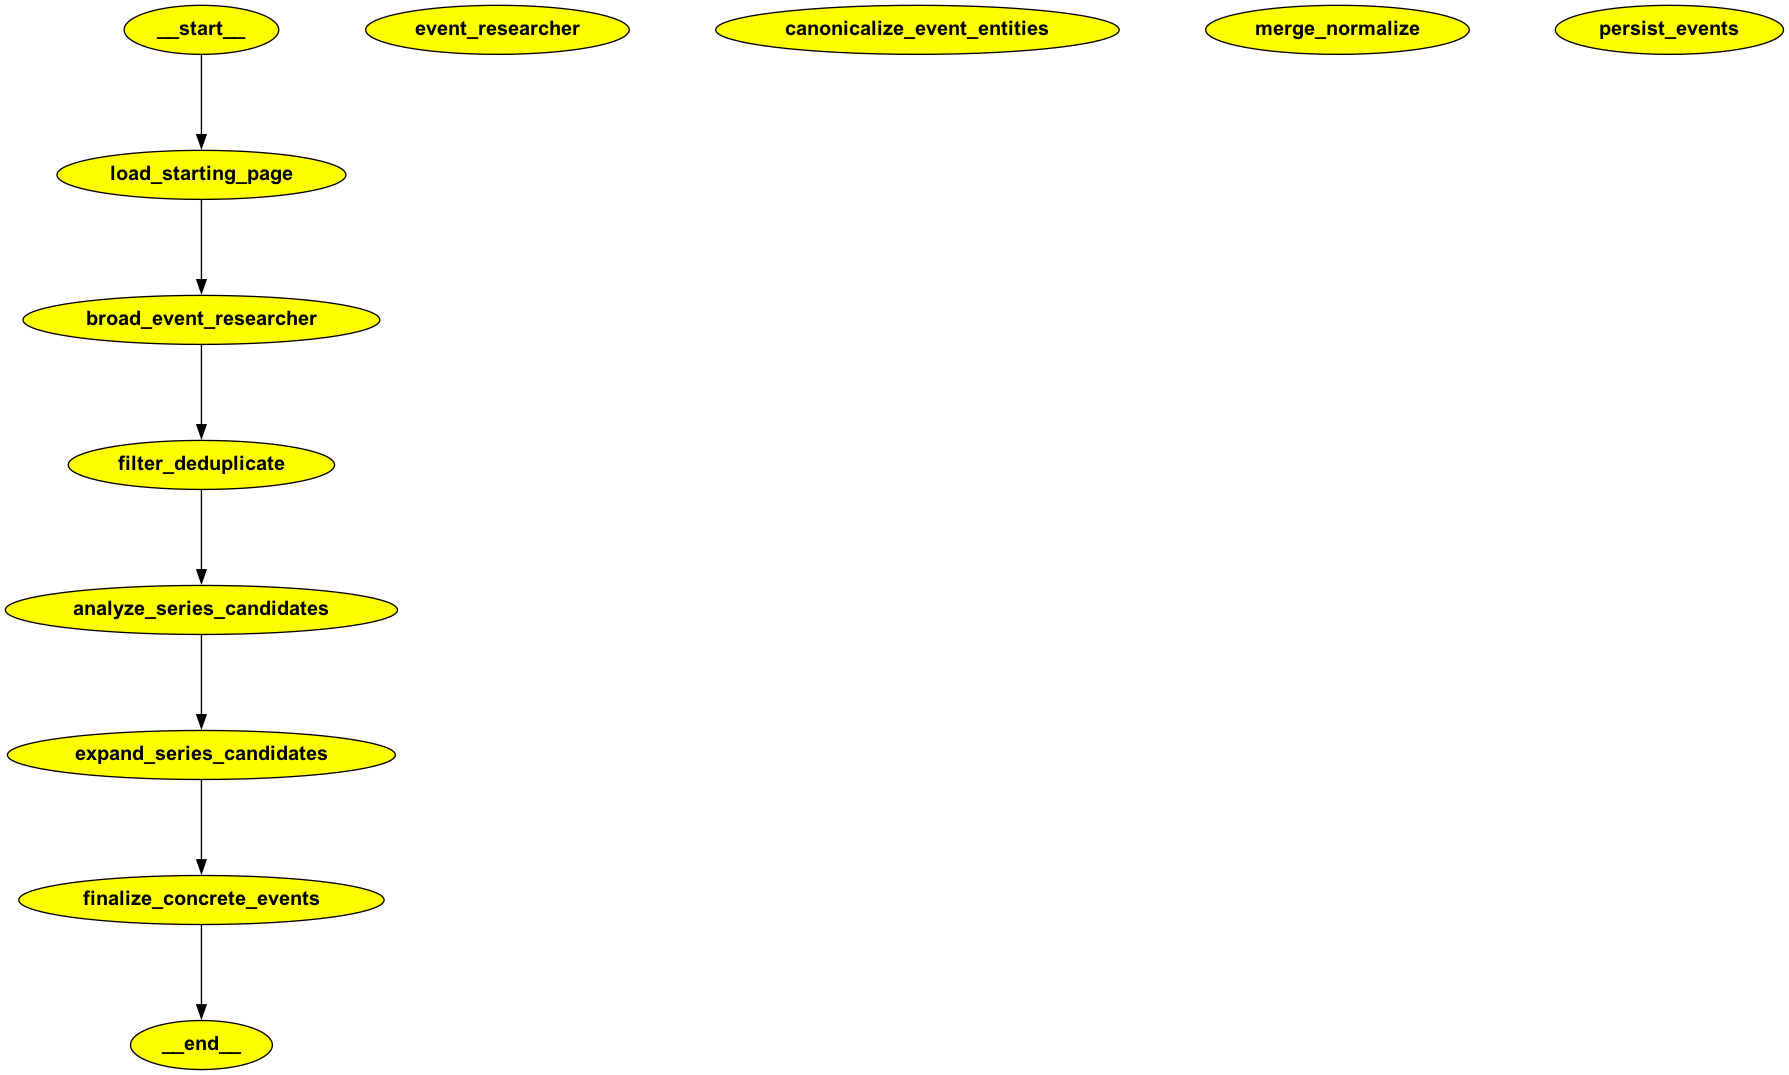

In [17]:
from IPython.display import Image

Image(graph.get_graph().draw_png())

In [18]:

pipeline_result = await graph.ainvoke({
    "starting_page_url": starting_page_url,
    "final_events": [],
})

final_events = pipeline_result.get("final_events", [])
print(json.dumps(final_events, ensure_ascii=True, indent=2))

final_events

[load_starting_page] Start: loading starting URL -> https://www.jacksonholechamber.com/events/
[load_starting_page] Done: prepared page payload (loaded_page_url=https://www.jacksonholechamber.com/events/, text_chars=74551)
[broad_event_researcher] Start: extracting rough event stubs from starting page (source_url=https://www.jacksonholechamber.com/events/)
[broad_event_researcher] Done: found 12 raw event candidates (event_secondary_url cleared for discovery phase)
[filter_deduplicate] Start: filtering and deduplicating 12 event candidates
[filter_deduplicate] Done: kept=12, removed_non_events=0, removed_duplicates=0
[analyze_series_candidates] Start: classifying 12 events
[analyze_series_candidates] Done: single_or_recurring=12, series_hubs=0
[expand_series_candidates] Start: expanding 0 series hubs
[expand_series_candidates] Done: expanded_children=0, unresolved_series=0
[finalize_concrete_events] Start: consolidating concrete events (single_or_recurring=12, unresolved_series=0, expa

[{'event_name': 'Industry Night',
  'date': 'Recurring weekly on Monday',
  'time': '8:30 PM – 12:00 AM',
  'source_url': 'https://www.jacksonholechamber.com/events/',
  'event_main_url': 'https://www.jacksonholechamber.com/event/industry-night/2245/',
  'event_secondary_url': 'https://outboundhotels.com/the-virginian/happening/industry-night/2026-11-16/',
  'event_address': '750 W Broadway, Jackson, WY 83001',
  'venue_name': 'Virginian Saloon',
  'host_organization_name': 'Virginian Saloon',
  'event_description': 'Every Monday night at the Virginian Saloon: games and rotating themes with bingo, trivia, surprise pop-up events and tournaments hosted by Jack Payne. Late-night happy hour and food/drink specials (examples: $7 Tall Boy + Shot; $8 Ferrari Shot; $9 Industry Margarita; $11 burger; $11 steak tacos; wings, fries, chips & dip). Must be 21+ to attend. Free admission.',
  'event_status': 'recurring'},
 {'event_name': 'Two for One Breakfast Entrees at the Wild Sage',
  'date': 'Ap

In [19]:
print(final_events)

[{'event_name': 'Industry Night', 'date': 'Recurring weekly on Monday', 'time': '8:30 PM – 12:00 AM', 'source_url': 'https://www.jacksonholechamber.com/events/', 'event_main_url': 'https://www.jacksonholechamber.com/event/industry-night/2245/', 'event_secondary_url': 'https://outboundhotels.com/the-virginian/happening/industry-night/2026-11-16/', 'event_address': '750 W Broadway, Jackson, WY 83001', 'venue_name': 'Virginian Saloon', 'host_organization_name': 'Virginian Saloon', 'event_description': 'Every Monday night at the Virginian Saloon: games and rotating themes with bingo, trivia, surprise pop-up events and tournaments hosted by Jack Payne. Late-night happy hour and food/drink specials (examples: $7 Tall Boy + Shot; $8 Ferrari Shot; $9 Industry Margarita; $11 burger; $11 steak tacos; wings, fries, chips & dip). Must be 21+ to attend. Free admission.', 'event_status': 'recurring'}, {'event_name': 'Two for One Breakfast Entrees at the Wild Sage', 'date': 'April 6, 2026 - May 9, 20